<a href="https://colab.research.google.com/github/ai-agent-yonsei/agent/blob/main/3_2_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph Reasoning → Planning Strategy → Planning
### One LLM, Different Planning Strategies

이 노트북은 **하나의 OpenAI LLM**을 사용하면서 질문의 성격에 따라 서로 다른 Planning 전략을 선택하는 과정을 LangGraph로 구현

구조:

`START → Reasoning → Planning Strategy Router → {No Plan | Simple Plan | Search Plan | Multi-step Plan} → Validation → END`

핵심 메시지:
- **Reasoning**: 요청의 성격과 필요한 계획 수준을 판단
- **Planning Strategy**: 문제 성격에 맞는 계획 방식 선택
- **Planning**: 같은 LLM이 선택된 전략에 따라 계획 생성
- **Validation**: 계획의 기본 품질 확인

기본 API Key는 Google Colab Secrets의 `OPENAI_API_KEY`를 사용

In [1]:
# 1. 패키지 설치
!pip -q install -U langgraph langchain-core langchain-openai networkx matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 136.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [2]:
# 2. Colab 한글 폰트 설정
!apt-get -qq update
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(FONT_PATH)

KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
KOREAN_FONT_NAME = KOREAN_FONT.get_name()

plt.rcParams["font.family"] = KOREAN_FONT_NAME
plt.rcParams["axes.unicode_minus"] = False
mpl.rcParams["font.family"] = KOREAN_FONT_NAME

print("한글 폰트 설정 완료:", KOREAN_FONT_NAME)

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
한글 폰트 설정 완료: NanumGothic


In [3]:
# 3. Colab Secrets에서 OpenAI API Key 로드
import os
from google.colab import userdata

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("Colab Secrets에 OPENAI_API_KEY를 등록해 주세요.")

os.environ["OPENAI_API_KEY"] = api_key
print("OPENAI_API_KEY loaded:", bool(os.getenv("OPENAI_API_KEY")))

OPENAI_API_KEY loaded: True


In [4]:
# 4. 공통 OpenAI LLM
# Reasoning과 모든 Planning 전략이 동일한 LLM을 사용합니다.

from langchain_openai import ChatOpenAI

MODEL_NAME = "gpt-5.6"

llm = ChatOpenAI(model=MODEL_NAME)

print("공통 LLM:", MODEL_NAME)

공통 LLM: gpt-5.6


In [5]:
# 5. LangGraph State 정의
from typing import TypedDict, Literal, List
from langgraph.graph import StateGraph, START, END

PlanningMode = Literal[
    "no_plan",
    "simple_plan",
    "search_plan",
    "multi_step_plan"
]

class AgentState(TypedDict, total=False):
    request: str

    task_type: str
    reasoning_summary: str
    planning_needed: bool
    planning_mode: PlanningMode
    planning_reason: str

    plan_summary: str
    plan: List[str]

    validation_status: str
    validation_message: str

    execution_path: List[str]
    trace: List[dict]

print("AgentState 정의 완료")

AgentState 정의 완료


In [6]:
# 6. 공통 Utility
import json
import re

def append_path(state, node):
    return state.get("execution_path", []) + [node]

def append_trace(state, node, detail):
    return state.get("trace", []) + [{"node": node, "detail": detail}]

def extract_json_object(text: str):
    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?\\s*", "", cleaned)
    cleaned = re.sub(r"\\s*```$", "", cleaned)

    try:
        return json.loads(cleaned)
    except Exception:
        match = re.search(r"\\{.*\\}", cleaned, flags=re.S)
        if not match:
            raise ValueError(f"JSON 객체를 찾지 못했습니다. 원본 응답:\n{text}")
        return json.loads(match.group(0))

In [7]:
# 7. Reasoning Node
# 요청의 성격과 필요한 Planning 수준을 판단합니다.
# 숨겨진 CoT가 아니라 짧고 구조화된 판단 결과만 출력합니다.

REASONING_PROMPT = """
당신은 AI Agent의 Reasoning 모듈이다.

사용자의 요청을 분석하여 어떤 종류의 작업인지,
그리고 어느 정도의 Planning이 필요한지 판단하라.

내부 chain-of-thought는 출력하지 말고,
운영에 필요한 간결한 판단 결과만 출력하라.

Planning mode는 반드시 다음 네 가지 중 하나다.

1. no_plan
- 단순 사실 질문
- 즉시 처리 가능한 요청
- 단계적 계획이 사실상 필요 없는 경우

2. simple_plan
- 2~4단계 정도의 짧은 순서가 필요한 요청
- 비교적 명확하고 단순한 실행 과제

3. search_plan
- 외부 정보, 검색, 데이터 수집, 문서 확인이 핵심인 요청
- 정보를 먼저 수집한 뒤 분석해야 하는 과제

4. multi_step_plan
- 복잡한 프로젝트
- 여러 단계와 의존관계가 있는 작업
- 설계, 분석, 구현, 검증 등이 순차적으로 필요한 과제

반드시 다음 JSON 형식만 출력하라.

{
  "task_type": "작업 유형",
  "reasoning_summary": "요청 특성을 1~2문장으로 설명",
  "planning_needed": true,
  "planning_mode": "no_plan | simple_plan | search_plan | multi_step_plan",
  "planning_reason": "해당 Planning mode 선택 이유"
}
"""

def reasoning_node(state: AgentState):
    response = llm.invoke([
        ("system", REASONING_PROMPT),
        ("human", state["request"])
    ])

    text = response.content if isinstance(response.content, str) else str(response.content)
    result = extract_json_object(text)
    mode = result["planning_mode"]

    return {
        "task_type": result.get("task_type", ""),
        "reasoning_summary": result.get("reasoning_summary", ""),
        "planning_needed": result.get("planning_needed", mode != "no_plan"),
        "planning_mode": mode,
        "planning_reason": result.get("planning_reason", ""),
        "execution_path": append_path(state, "reasoning"),
        "trace": append_trace(
            state,
            "reasoning",
            f"task_type={result.get('task_type')} | planning_mode={mode} | reason={result.get('planning_reason')}"
        )
    }

def planning_strategy_router(state: AgentState) -> str:
    return state["planning_mode"]

In [8]:
# 8. No Plan Node

def no_plan_node(state: AgentState):
    return {
        "plan_summary": "별도의 단계적 Planning이 필요하지 않은 요청",
        "plan": ["요청을 직접 처리한다."],
        "execution_path": append_path(state, "no_plan"),
        "trace": append_trace(
            state,
            "no_plan",
            "별도의 단계적 Planning 없이 직접 처리 가능한 요청"
        )
    }

In [9]:
# 9. Simple Plan Node

SIMPLE_PLAN_PROMPT = """
당신은 AI Agent의 Simple Planning 모듈이다.

사용자의 요청과 앞 단계의 Reasoning 결과를 바탕으로
짧고 명확한 실행 계획을 작성하라.

규칙:
- 2~4단계
- 불필요하게 세분화하지 않는다.
- 각 단계는 실행 가능한 action 형태
- 숨겨진 사고과정은 출력하지 않는다.

반드시 JSON만 출력하라.

{
  "summary": "계획의 전체 방향",
  "steps": [
    "1단계 ...",
    "2단계 ..."
  ]
}
"""

def simple_plan_node(state: AgentState):
    context = f"""
사용자 요청:
{state['request']}

Reasoning 결과:
- Task Type: {state['task_type']}
- 판단: {state['reasoning_summary']}
- Planning 선택 이유: {state['planning_reason']}
"""

    response = llm.invoke([
        ("system", SIMPLE_PLAN_PROMPT),
        ("human", context)
    ])

    text = response.content if isinstance(response.content, str) else str(response.content)
    result = extract_json_object(text)

    return {
        "plan_summary": result.get("summary", ""),
        "plan": result.get("steps", []),
        "execution_path": append_path(state, "simple_plan"),
        "trace": append_trace(
            state,
            "simple_plan",
            f"generated_steps={len(result.get('steps', []))}"
        )
    }

In [10]:
# 10. Search Plan Node
# 실제 검색을 수행하는 노드가 아니라
# "어떤 정보를 어떤 순서로 조사할지" 계획하는 노드입니다.

SEARCH_PLAN_PROMPT = """
당신은 AI Agent의 Search Planning 모듈이다.

사용자의 요청을 해결하기 위해
어떤 정보를 어떤 순서로 수집하고 검증할지 계획하라.

규칙:
- 4~6단계
- 검색 대상 또는 정보 소스를 명시
- 수집 → 비교/검증 → 분석 → 결과 통합 흐름
- 실제 검색 결과는 만들지 않는다.
- 숨겨진 사고과정은 출력하지 않는다.

반드시 JSON만 출력하라.

{
  "summary": "검색 중심 계획의 전체 방향",
  "steps": [
    "1단계 ...",
    "2단계 ...",
    "3단계 ..."
  ]
}
"""

def search_plan_node(state: AgentState):
    context = f"""
사용자 요청:
{state['request']}

Reasoning 결과:
- Task Type: {state['task_type']}
- 판단: {state['reasoning_summary']}
- Planning 선택 이유: {state['planning_reason']}
"""

    response = llm.invoke([
        ("system", SEARCH_PLAN_PROMPT),
        ("human", context)
    ])

    text = response.content if isinstance(response.content, str) else str(response.content)
    result = extract_json_object(text)

    return {
        "plan_summary": result.get("summary", ""),
        "plan": result.get("steps", []),
        "execution_path": append_path(state, "search_plan"),
        "trace": append_trace(
            state,
            "search_plan",
            f"generated_steps={len(result.get('steps', []))}"
        )
    }

In [11]:
# 11. Multi-step Plan Node

MULTI_STEP_PLAN_PROMPT = """
당신은 AI Agent의 Multi-step Planning 모듈이다.

사용자의 복잡한 목표를 실행 가능한 하위 작업으로 분해하고,
선후관계와 검증 단계를 포함한 계획을 작성하라.

규칙:
- 5~8단계
- 단계 간 의존관계가 드러나야 한다.
- 필요한 입력, 도구 또는 산출물을 고려한다.
- 중간 검증 또는 완료 조건을 포함한다.
- 필요하면 리스크/예외 확인 단계를 포함한다.
- 숨겨진 사고과정은 출력하지 않는다.

반드시 JSON만 출력하라.

{
  "summary": "전체 Multi-step 계획",
  "steps": [
    "1단계 ...",
    "2단계 ...",
    "3단계 ..."
  ]
}
"""

def multi_step_plan_node(state: AgentState):
    context = f"""
사용자 요청:
{state['request']}

Reasoning 결과:
- Task Type: {state['task_type']}
- 판단: {state['reasoning_summary']}
- Planning 선택 이유: {state['planning_reason']}
"""

    response = llm.invoke([
        ("system", MULTI_STEP_PLAN_PROMPT),
        ("human", context)
    ])

    text = response.content if isinstance(response.content, str) else str(response.content)
    result = extract_json_object(text)

    return {
        "plan_summary": result.get("summary", ""),
        "plan": result.get("steps", []),
        "execution_path": append_path(state, "multi_step_plan"),
        "trace": append_trace(
            state,
            "multi_step_plan",
            f"generated_steps={len(result.get('steps', []))}"
        )
    }

In [12]:
# 12. Plan Validation Node

def validate_plan(state: AgentState):
    mode = state["planning_mode"]
    plan = state.get("plan", [])

    expected_ranges = {
        "no_plan": (1, 2),
        "simple_plan": (2, 4),
        "search_plan": (4, 6),
        "multi_step_plan": (5, 8),
    }

    min_steps, max_steps = expected_ranges[mode]
    issues = []

    if len(plan) < min_steps:
        issues.append(
            f"{mode}에 비해 단계가 너무 적음 "
            f"(현재 {len(plan)}, 기대 {min_steps}~{max_steps})"
        )

    if len(plan) > max_steps:
        issues.append(
            f"{mode}에 비해 단계가 너무 많음 "
            f"(현재 {len(plan)}, 기대 {min_steps}~{max_steps})"
        )

    if any(not str(step).strip() for step in plan):
        issues.append("비어 있는 계획 단계 존재")

    if issues:
        status = "REVIEW"
        message = "; ".join(issues)
    else:
        status = "PASS"
        message = f"{mode} 전략에 적합한 {len(plan)}개 단계가 생성됨"

    return {
        "validation_status": status,
        "validation_message": message,
        "execution_path": append_path(state, "validate_plan"),
        "trace": append_trace(
            state,
            "validate_plan",
            f"status={status} | {message}"
        )
    }

In [13]:
# 13. LangGraph 구성

builder = StateGraph(AgentState)

builder.add_node("reasoning", reasoning_node)
builder.add_node("no_plan", no_plan_node)
builder.add_node("simple_plan", simple_plan_node)
builder.add_node("search_plan", search_plan_node)
builder.add_node("multi_step_plan", multi_step_plan_node)
builder.add_node("validate_plan", validate_plan)

builder.add_edge(START, "reasoning")

builder.add_conditional_edges(
    "reasoning",
    planning_strategy_router,
    {
        "no_plan": "no_plan",
        "simple_plan": "simple_plan",
        "search_plan": "search_plan",
        "multi_step_plan": "multi_step_plan",
    }
)

builder.add_edge("no_plan", "validate_plan")
builder.add_edge("simple_plan", "validate_plan")
builder.add_edge("search_plan", "validate_plan")
builder.add_edge("multi_step_plan", "validate_plan")
builder.add_edge("validate_plan", END)

graph = builder.compile()

print("LangGraph compile 완료")

LangGraph compile 완료


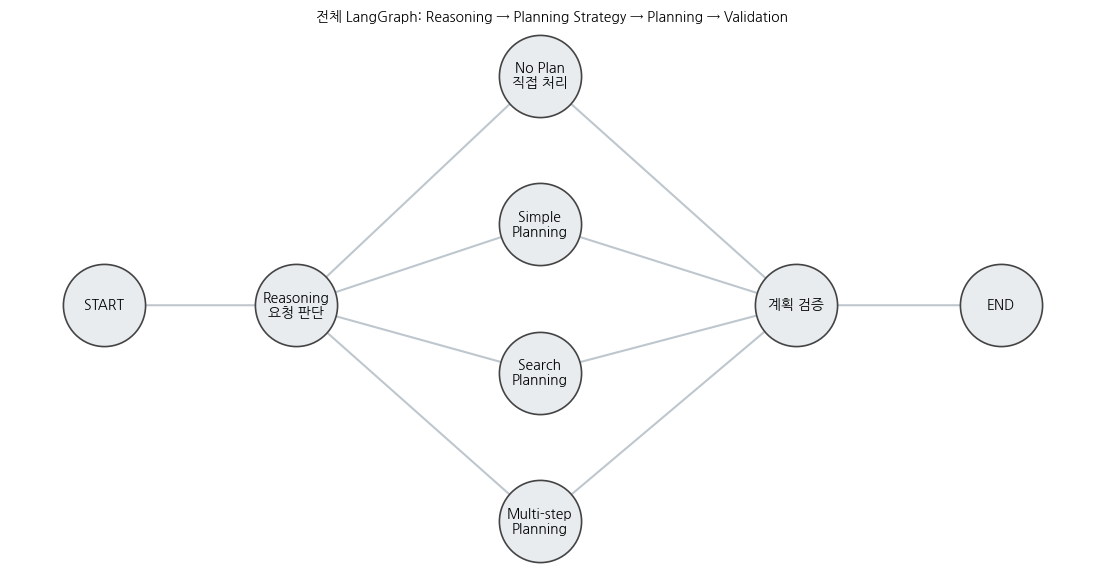

In [14]:
# 14. 전체 그래프 구조 시각화

import networkx as nx
import matplotlib.pyplot as plt

ALL_NODES = [
    "START", "reasoning",
    "no_plan", "simple_plan", "search_plan", "multi_step_plan",
    "validate_plan", "END"
]

ALL_EDGES = [
    ("START", "reasoning"),
    ("reasoning", "no_plan"),
    ("reasoning", "simple_plan"),
    ("reasoning", "search_plan"),
    ("reasoning", "multi_step_plan"),
    ("no_plan", "validate_plan"),
    ("simple_plan", "validate_plan"),
    ("search_plan", "validate_plan"),
    ("multi_step_plan", "validate_plan"),
    ("validate_plan", "END"),
]

POS = {
    "START": (0, 3),
    "reasoning": (1.5, 3),
    "no_plan": (3.4, 4.7),
    "simple_plan": (3.4, 3.6),
    "search_plan": (3.4, 2.5),
    "multi_step_plan": (3.4, 1.4),
    "validate_plan": (5.4, 3),
    "END": (7.0, 3),
}

LABELS = {
    "START": "START",
    "reasoning": "Reasoning\n요청 판단",
    "no_plan": "No Plan\n직접 처리",
    "simple_plan": "Simple\nPlanning",
    "search_plan": "Search\nPlanning",
    "multi_step_plan": "Multi-step\nPlanning",
    "validate_plan": "계획 검증",
    "END": "END",
}

def visualize_full_graph():
    G = nx.DiGraph()
    G.add_nodes_from(ALL_NODES)
    G.add_edges_from(ALL_EDGES)

    plt.figure(figsize=(14, 7))

    nx.draw_networkx_nodes(
        G, POS,
        node_size=3500,
        node_color="#E8ECEF",
        edgecolors="#444444",
        linewidths=1.2
    )

    nx.draw_networkx_edges(
        G, POS,
        edge_color="#BFC7CE",
        width=1.5,
        arrows=True,
        arrowsize=20
    )

    nx.draw_networkx_labels(
        G, POS,
        labels=LABELS,
        font_size=10,
        font_family=KOREAN_FONT_NAME
    )

    plt.title(
        "전체 LangGraph: Reasoning → Planning Strategy → Planning → Validation",
        fontsize=16,
        fontproperties=KOREAN_FONT
    )

    plt.axis("off")
    plt.show()

visualize_full_graph()

In [15]:
# 15. 실제 실행 경로 시각화

def visualize_execution(result: AgentState):
    actual_path = ["START"] + result["execution_path"] + ["END"]
    actual_edges = list(zip(actual_path[:-1], actual_path[1:]))

    G = nx.DiGraph()
    G.add_nodes_from(ALL_NODES)
    G.add_edges_from(ALL_EDGES)

    visited = set(actual_path)

    node_colors = [
        "#B8E0D2" if n in visited else "#E9ECEF"
        for n in ALL_NODES
    ]

    plt.figure(figsize=(14, 7))

    nx.draw_networkx_edges(
        G, POS,
        edgelist=ALL_EDGES,
        edge_color="#C7CDD3",
        width=1.2,
        arrows=True,
        arrowsize=18
    )

    nx.draw_networkx_edges(
        G, POS,
        edgelist=actual_edges,
        edge_color="#D1495B",
        width=4.0,
        arrows=True,
        arrowsize=24
    )

    nx.draw_networkx_nodes(
        G, POS,
        node_color=node_colors,
        node_size=3500,
        edgecolors="#444444",
        linewidths=1.3
    )

    nx.draw_networkx_labels(
        G, POS,
        labels=LABELS,
        font_size=10,
        font_family=KOREAN_FONT_NAME
    )

    mode = result["planning_mode"]

    plt.title(
        f"실제 실행 경로 — 선택된 Planning Strategy: {mode}",
        fontsize=16,
        fontproperties=KOREAN_FONT
    )

    plt.text(
        3.5, 0.45,
        "실제 경로: " + " → ".join(actual_path),
        ha="center",
        fontsize=11,
        fontproperties=KOREAN_FONT
    )

    plt.axis("off")
    plt.show()

In [16]:
# 16. 결과 출력 함수

def print_result(result: AgentState):
    print("=" * 85)

    print("1. 사용자 요청")
    print(result["request"])

    print("\n2. Reasoning 결과")
    print("Task Type       :", result["task_type"])
    print("Reasoning 요약  :", result["reasoning_summary"])
    print("Planning 필요   :", result["planning_needed"])
    print("Planning Mode   :", result["planning_mode"])
    print("선택 이유       :", result["planning_reason"])

    print("\n3. Planning 결과")
    print("요약:", result["plan_summary"])

    for i, step in enumerate(result["plan"], 1):
        print(f"  {i}. {step}")

    print("\n4. Validation")
    print(result["validation_status"], "-", result["validation_message"])

    print("\n5. 실제 실행 Path")
    print("START → " + " → ".join(result["execution_path"]) + " → END")

    print("\n6. Trace")
    for i, item in enumerate(result["trace"], 1):
        print(f"[{i}] {item['node']}: {item['detail']}")

1. 사용자 요청

우리 회사 고객 상담 업무에 AI Agent를 도입하려고 한다.
현재 프로세스를 분석하고 필요한 데이터와 도구를 정의한 뒤,
PoC부터 운영 배포까지 단계별 계획을 만들어 줘.


2. Reasoning 결과
Task Type       : 고객 상담 AI Agent 도입 전략 및 실행 로드맵 수립
Reasoning 요약  : 현재 상담 프로세스 분석, 데이터·도구 정의, PoC 설계, 성능 검증, 운영 배포까지 상호 의존적인 여러 단계가 필요한 복합 프로젝트다.
Planning 필요   : True
Planning Mode   : multi_step_plan
선택 이유       : 업무 분석부터 아키텍처와 데이터 준비, PoC 구현, 평가·보안 검증, 시스템 연동, 운영 전환 및 모니터링까지 순차적인 설계·구현·검증이 필요하기 때문이다.

3. Planning 결과
요약: 현재 고객 상담 프로세스와 요구사항을 진단하고, 데이터·도구·아키텍처를 정의한 뒤 제한된 범위의 PoC를 구현·검증한다. 이후 보안 및 시스템 연동을 완료하고 단계적으로 운영 배포하며 성능과 리스크를 지속 관리한다.
  1. 1단계 — 목표·범위·성공 기준 수립: 고객센터 책임자, 상담사, IT, 보안·법무 등 이해관계자를 확정하고 상담 채널, 대상 고객, 자동화할 업무 범위와 제외 범위를 정의한다. 입력은 상담량, 평균 처리 시간, 해결률, 고객 만족도, 운영 비용 등 현행 지표이며, 산출물은 우선순위 업무 목록과 KPI 기준선이다. 완료 조건은 자동 해결률, 응답 정확도, 처리 시간, 상담사 전환율, 고객 만족도 및 허용 오류율이 수치로 합의되는 것이다.
  2. 2단계 — 현재 상담 프로세스 분석: 1단계의 범위를 기준으로 문의 접수부터 본인 확인, 지식 검색, 답변, 업무 처리, 상담사 이관, 사후 기록까지의 흐름을 인터뷰, 상담 로그 분석, 프로세스 마이닝 도구로 분석한다. 문의 유형별 빈도·난도·위험도와 병목, 예외, 반복 업무를 파악하고 AI 자동화·상담사

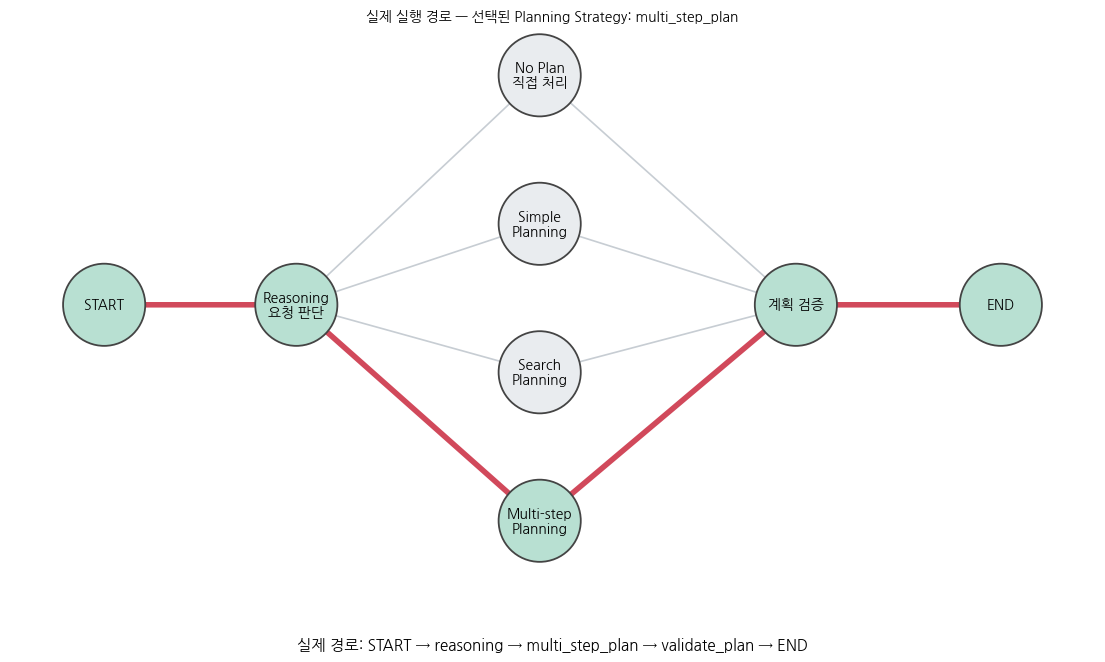

In [17]:
# 17. 단일 요청 실행

request = '''
우리 회사 고객 상담 업무에 AI Agent를 도입하려고 한다.
현재 프로세스를 분석하고 필요한 데이터와 도구를 정의한 뒤,
PoC부터 운영 배포까지 단계별 계획을 만들어 줘.
'''

result = graph.invoke({
    "request": request,
    "execution_path": [],
    "trace": []
})

print_result(result)
visualize_execution(result)



####################################################################################################
# No Plan 후보
####################################################################################################
1. 사용자 요청

    RAG는 무엇의 약자인가?
    

2. Reasoning 결과
Task Type       : 단순 사실 질문
Reasoning 요약  : RAG 약어의 원래 표현을 묻는 즉답형 질문이다.
Planning 필요   : False
Planning Mode   : no_plan
선택 이유       : 단계적 계획이나 외부 정보 검색 없이 바로 답할 수 있다.

3. Planning 결과
요약: 별도의 단계적 Planning이 필요하지 않은 요청
  1. 요청을 직접 처리한다.

4. Validation
PASS - no_plan 전략에 적합한 1개 단계가 생성됨

5. 실제 실행 Path
START → reasoning → no_plan → validate_plan → END

6. Trace
[1] reasoning: task_type=단순 사실 질문 | planning_mode=no_plan | reason=단계적 계획이나 외부 정보 검색 없이 바로 답할 수 있다.
[2] no_plan: 별도의 단계적 Planning 없이 직접 처리 가능한 요청
[3] validate_plan: status=PASS | no_plan 전략에 적합한 1개 단계가 생성됨


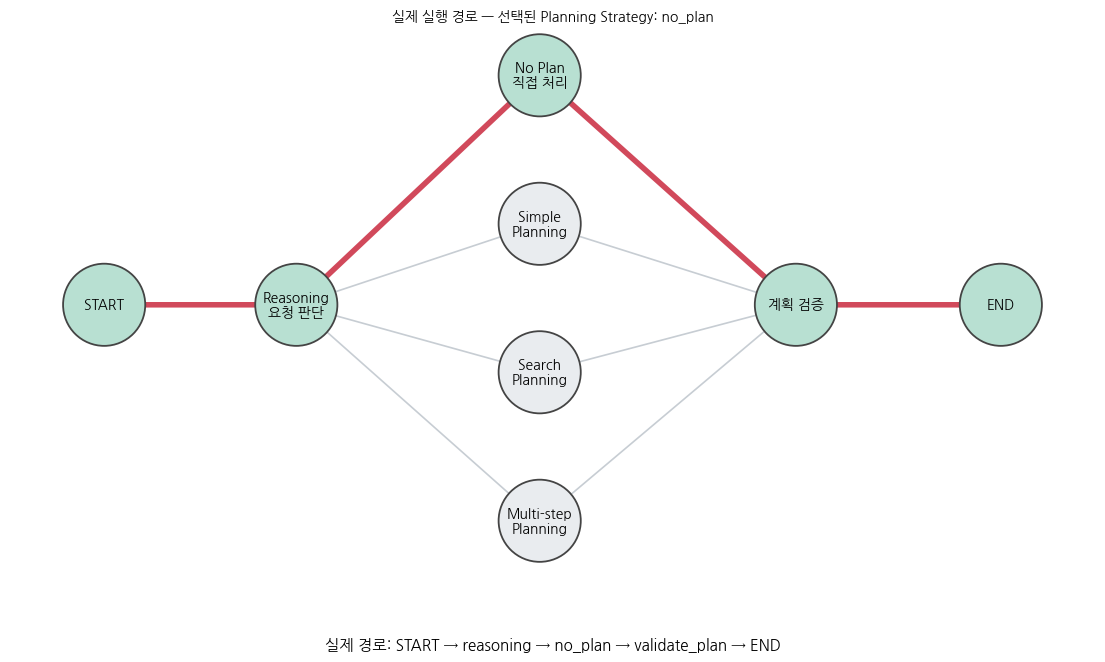



####################################################################################################
# Simple Plan 후보
####################################################################################################
1. 사용자 요청

    내일 오전에 팀 회의를 준비해야 한다.
    회의 전에 해야 할 일을 간단히 정리해 줘.
    

2. Reasoning 결과
Task Type       : 회의 준비 체크리스트 작성
Reasoning 요약  : 내일 오전 팀 회의 전에 수행할 준비 업무를 간단한 순서로 정리하는 요청이다.
Planning 필요   : True
Planning Mode   : simple_plan
선택 이유       : 안건 확인, 자료 준비, 참석자 공유, 장비 점검 등 몇 단계의 짧은 실행 계획이 필요하다.

3. Planning 결과
요약: 팀 회의의 안건과 자료를 준비하고, 참석자 공유 및 환경 점검까지 완료한다.
  1. 1단계 회의 목적과 주요 안건을 확인하고 우선순위를 정한다.
  2. 2단계 필요한 자료와 진행 현황을 정리해 회의 문서를 준비한다.
  3. 3단계 참석자에게 일정과 안건, 준비 자료를 미리 공유한다.
  4. 4단계 회의 직전에 장소, 화상회의 링크, 화면 공유 등 장비를 점검한다.

4. Validation
PASS - simple_plan 전략에 적합한 4개 단계가 생성됨

5. 실제 실행 Path
START → reasoning → simple_plan → validate_plan → END

6. Trace
[1] reasoning: task_type=회의 준비 체크리스트 작성 | planning_mode=simple_plan | reason=안건 확인, 자료 준비, 참석자 공유, 장비 점검 등 몇 단계의 짧은 실행 계

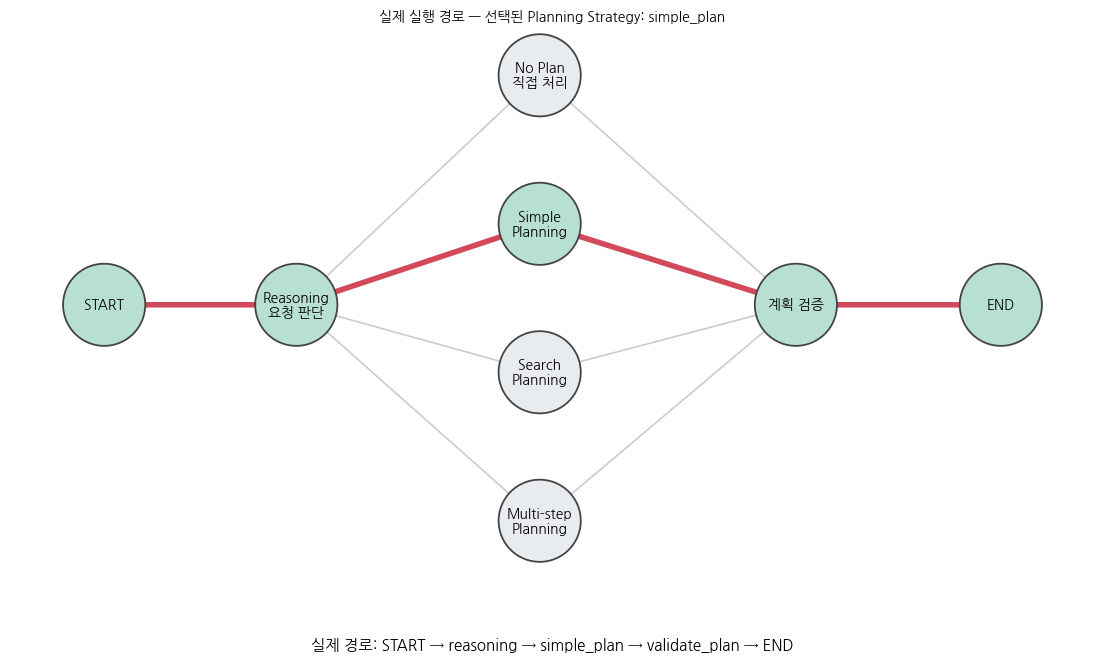



####################################################################################################
# Search Plan 후보
####################################################################################################
1. 사용자 요청

    서울 지역 대학의 생성형 AI 관련 최근 강의를 조사하고,
    어떤 주제를 많이 다루는지 비교하기 위한 조사 계획을 만들어 줘.
    

2. Reasoning 결과
Task Type       : 교육과정 조사 및 비교 분석 계획 수립
Reasoning 요약  : 서울 소재 대학들의 최근 생성형 AI 관련 강의 정보를 외부 자료에서 수집하고, 강의별 주제를 분류해 공통점과 차이를 비교해야 하는 요청이다.
Planning 필요   : True
Planning Mode   : search_plan
선택 이유       : 대학 강의계획서, 교과목 안내, 공개강좌 등 최신 외부 정보를 먼저 검색·검증한 뒤 주제 빈도와 경향을 분석하는 것이 핵심이기 때문이다.

3. Planning 결과
요약: 서울 소재 대학의 공식 교과과정·강의계획서·공개강좌 자료를 중심으로 최근 생성형 AI 관련 강의를 수집하고, 개설 시점과 내용의 신뢰성을 검증한 뒤 공통 주제 체계로 분류하여 빈도와 대학별 차이를 비교한다.
  1. 1단계: 조사 범위와 기준을 설정한다. 서울 소재 대학의 학부·대학원 정규 교과목 및 대학 공식 공개강좌를 대상으로 하고, ‘최근’의 기준 학기, 생성형 AI 관련성 판단 조건, 비교할 항목(대학명, 강의명, 개설 시기, 학과, 대상, 핵심 주제, 실습 도구)을 정의한다.
  2. 2단계: 각 대학의 공식 홈페이지, 교과과정 조회 시스템, 강의계획서 데이터베이스, 대학원·학과 공지, 공개강좌 플랫폼에서 ‘생성형 AI’, ‘생성 AI’, ‘Ge

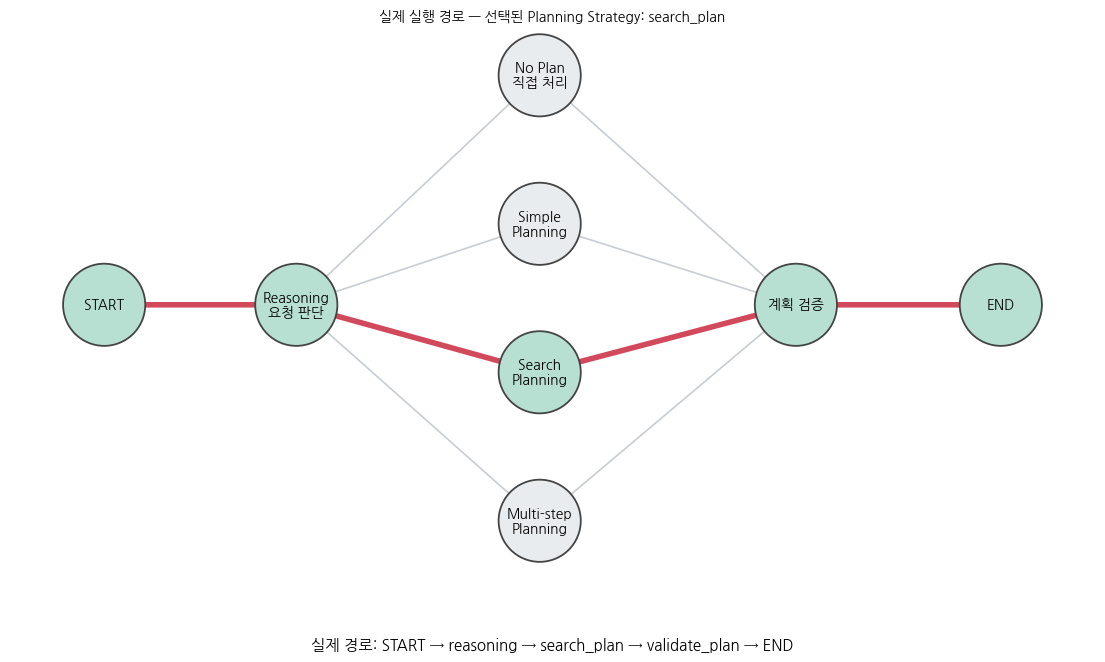



####################################################################################################
# Multi-step Plan 후보
####################################################################################################
1. 사용자 요청

    금융회사에 AI Agent를 도입하려고 한다.
    업무 선정, 데이터 준비, 아키텍처 설계, PoC, 평가,
    보안 검토, 운영 배포까지 전체 프로젝트 계획을 만들어 줘.
    

2. Reasoning 결과
Task Type       : 금융회사 AI Agent 도입 프로젝트 계획 수립
Reasoning 요약  : 업무 선정부터 데이터 준비, 아키텍처 설계, PoC, 평가, 보안 검토, 운영 배포까지 전 과정을 설계하는 복합 프로젝트다. 금융권 규제와 보안, 단계별 검증 및 선후 의존관계도 함께 고려해야 한다.
Planning 필요   : True
Planning Mode   : multi_step_plan
선택 이유       : 다수의 이해관계자와 단계별 산출물이 필요하고, 업무·데이터·기술·보안·규제·운영 준비가 상호 의존하므로 체계적인 다단계 계획이 필요하다.

3. Planning 결과
요약: 금융회사 AI Agent 도입을 위해 거버넌스 수립과 업무 선정부터 데이터 준비, 아키텍처·통제 설계, PoC 구현, 성능·위험 평가, 보안·규제 승인, 운영 배포와 지속 모니터링까지 단계별 승인 게이트를 적용한다.
  1. 1단계 — 추진체계 및 규제 기준 수립: 경영진 스폰서, 현업, IT, 데이터, 정보보호, 준법감시, 법무, 리스크관리, 감사 담당자로 협의체를 구성한다. 적용 대상 법규·감독규정, 개인정보·신용정보 처리 기준, 망분리·클라우드 정책, 전자금융 관련 내부통제를 확인하고 프로젝트 범위·예산·일정·RACI와 

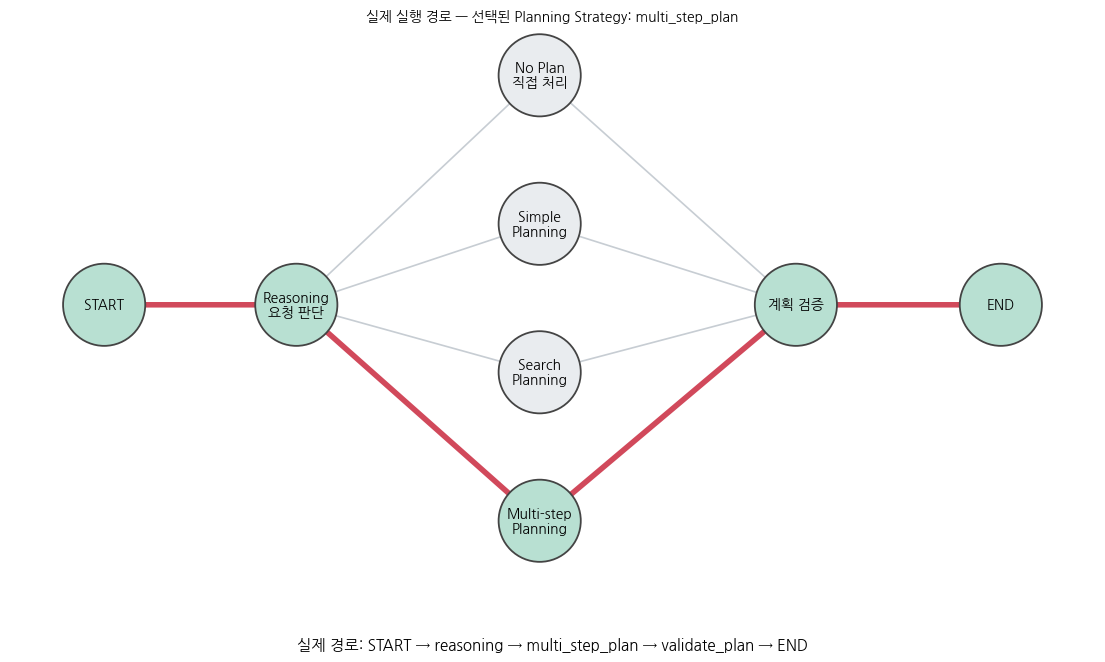

In [18]:
# 18. 네 가지 Planning Strategy 비교 실험

test_cases = {
    "No Plan 후보": '''
    RAG는 무엇의 약자인가?
    ''',

    "Simple Plan 후보": '''
    내일 오전에 팀 회의를 준비해야 한다.
    회의 전에 해야 할 일을 간단히 정리해 줘.
    ''',

    "Search Plan 후보": '''
    서울 지역 대학의 생성형 AI 관련 최근 강의를 조사하고,
    어떤 주제를 많이 다루는지 비교하기 위한 조사 계획을 만들어 줘.
    ''',

    "Multi-step Plan 후보": '''
    금융회사에 AI Agent를 도입하려고 한다.
    업무 선정, 데이터 준비, 아키텍처 설계, PoC, 평가,
    보안 검토, 운영 배포까지 전체 프로젝트 계획을 만들어 줘.
    '''
}

results = {}

for case_name, req in test_cases.items():
    print("\n\n" + "#" * 100)
    print("#", case_name)
    print("#" * 100)

    r = graph.invoke({
        "request": req,
        "execution_path": [],
        "trace": []
    })

    results[case_name] = r

    print_result(r)
    visualize_execution(r)

In [19]:
# 19. 네 Case 결과 요약표

import pandas as pd

rows = []

for case_name, r in results.items():
    rows.append({
        "Case": case_name,
        "Task Type": r["task_type"],
        "Planning Needed": r["planning_needed"],
        "Planning Strategy": r["planning_mode"],
        "Plan 단계 수": len(r["plan"]),
        "Validation": r["validation_status"],
        "실행 경로": " → ".join(
            ["START"] + r["execution_path"] + ["END"]
        )
    })

df = pd.DataFrame(rows)
display(df)

,Case,Task Type,Planning Needed,Planning Strategy,Plan 단계 수,Validation,실행 경로
0,No Plan 후보,단순 사실 질문,False,no_plan,1,PASS,START → reasoning → no_plan → validate_plan → END
1,Simple Plan 후보,회의 준비 체크리스트 작성,True,simple_plan,4,PASS,START → reasoning → simple_plan → validate_pla...
2,Search Plan 후보,교육과정 조사 및 비교 분석 계획 수립,True,search_plan,6,PASS,START → reasoning → search_plan → validate_pla...
3,Multi-step Plan 후보,금융회사 AI Agent 도입 프로젝트 계획 수립,True,multi_step_plan,8,PASS,START → reasoning → multi_step_plan → validate...


문제 성격에 따라

- 단순 사실 질문 → `No Plan`
- 짧은 실행 과제 → `Simple Plan`
- 조사/정보 수집 → `Search Plan`
- 복잡한 프로젝트 → `Multi-step Plan`

으로 나뉨

**Provider Routing이 아니라 Planning Strategy Routing**

`Reasoning → Planning → Tool Use → Observation → Reflection → Replanning → Action`

구조로 확장 가능